### Nowe podejście po decyzji o zrobieniu fuzji
1) Rezygnacja z ESG - Żeby nie było korelacji pomiędzy moim a Ali systemem (Ala również ma ESG w regułach)
2) Pozostawienie EarningsToGrowth, PricesToSales oraz ProfitMargin_WMA
3) Zmniejszenie liczby "kubełków" dla metryk: teraz są tylko "low", "midium" "high"
4) pozostawienie target score na 5 kategorii
5) zmiana kształtu membership functions dla target score na trapezoidalne

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path
import skfuzzy as fuzz

LOCAL_FOLDER = Path.cwd().parent.parent / "local_folder"
df = pd.read_csv(LOCAL_FOLDER / 'aggregated_company_data.csv')

### 3 zmienne wejściowe i TargetScore

In [11]:
from skfuzzy import control as ctrl

RESOLUTION = 1000
MIN_QUANTILE = 0.05
MAX_QUANTILE = 0.95

# =====================================================================
# 1. EARNINGS-TO-GROWTH
# =====================================================================
earnings_to_growth_min_val = df['Earnings-to-Growth'].quantile(MIN_QUANTILE)
earnings_to_growth_max_val = df['Earnings-to-Growth'].quantile(MAX_QUANTILE)
earnings_to_growth_step = (earnings_to_growth_max_val - earnings_to_growth_min_val) / RESOLUTION

earnings_to_growth_array = np.arange(earnings_to_growth_min_val, earnings_to_growth_max_val, earnings_to_growth_step)
earnings_to_growth_antecedent = ctrl.Antecedent(earnings_to_growth_array, 'Earnings-to-Growth')

# =====================================================================
# 3. PROFIT MARGIN MEAN
# =====================================================================
profit_margin_WMA_min_val = df['ProfitMargin_WMA'].quantile(MIN_QUANTILE)
profit_margin_WMA_max_val = df['ProfitMargin_WMA'].quantile(MAX_QUANTILE)
profit_margin_WMA_step = (profit_margin_WMA_max_val - profit_margin_WMA_min_val) / RESOLUTION

profit_margin_WMA_array = np.arange(profit_margin_WMA_min_val, profit_margin_WMA_max_val, profit_margin_WMA_step)
profit_margin_WMA_antecedent = ctrl.Antecedent(profit_margin_WMA_array, 'ProfitMargin_WMA')

# =====================================================================
# 4. PRICE-TO-SALES
# =====================================================================
price_to_sales_min_val = df['PriceToSales'].quantile(MIN_QUANTILE)
price_to_sales_max_val = df['PriceToSales'].quantile(MAX_QUANTILE)
price_to_sales_step = (price_to_sales_max_val - price_to_sales_min_val) / RESOLUTION

price_to_sales_array = np.arange(price_to_sales_min_val, price_to_sales_max_val, price_to_sales_step)
price_to_sales_antecedent = ctrl.Antecedent(price_to_sales_array, 'PriceToSales')

# =====================================================================
# TARGET SCORE (Wyjście / Consequent)
# =====================================================================
# Zostawiamy tak, jak napisałeś - tu chcemy mieć sztywny wynik np. od 0 do 100 punktów
TARGET_SCORE = ctrl.Consequent(np.arange(0, 101, 0.1), 'TARGET_SCORE')

#### 0) Przedziały

In [12]:
LOW_QUANTILE = 0.25
MID_QUANTILE = 0.5
HIGH_QUANTILE = 0.75

#### 1) Earnings-to-growth
Im NIŻSZY wynik ETG, tym lepsza firma

-0.23401000000000002 -0.17770000000000002 0.1327


c:\Users\majch\OneDrive\Dokumenty\Wojtek\STUDIA\SEMESTR_4\MSID\laby\MSiD_Project\.venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


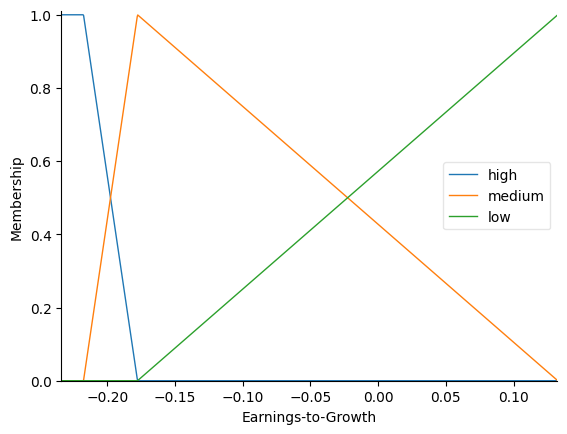

In [13]:
q_min = earnings_to_growth_min_val
q_low = df['Earnings-to-Growth'].quantile(LOW_QUANTILE)
q_mid = df['Earnings-to-Growth'].quantile(MID_QUANTILE)
q_high = df['Earnings-to-Growth'].quantile(HIGH_QUANTILE)
q_max = earnings_to_growth_max_val

print(q_min, q_mid, q_max)

universe_etg = earnings_to_growth_antecedent.universe

# 2. HIGH - TRAPEZ: Zaczyna się na górze (q_min), podstawa górna do q_low, kończy na środku (q_mid)
earnings_to_growth_antecedent['high'] = fuzz.trapmf(universe_etg, [q_min ,q_min, q_low, q_mid])

# 3. MEDIUM: Typowy środek rynku - symetryczny trójkąt wokół mediany (q_mid)
earnings_to_growth_antecedent['medium'] = fuzz.trimf(universe_etg, [q_low, q_mid, q_high])

# 4. LOW: Zaczyna się od środka (q_mid), szczytuje na q_high, kończy na maksimum (q_max)
earnings_to_growth_antecedent['low'] = fuzz.trapmf(universe_etg, [q_mid, q_high, q_max, q_max])

earnings_to_growth_antecedent.view()

#### 2) Profit Margin WMA
Im WYŻSZY wynik PMW, tym lepsza firma

c:\Users\majch\OneDrive\Dokumenty\Wojtek\STUDIA\SEMESTR_4\MSID\laby\MSiD_Project\.venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


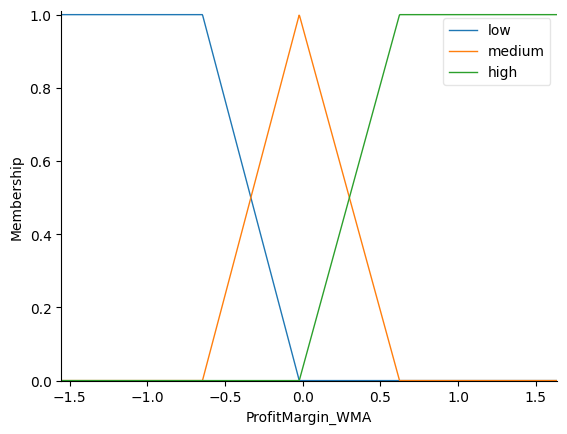

In [14]:
q_min = profit_margin_WMA_min_val
q_low = df['ProfitMargin_WMA'].quantile(LOW_QUANTILE)
q_mid = df['ProfitMargin_WMA'].quantile(MID_QUANTILE)
q_high = df['ProfitMargin_WMA'].quantile(HIGH_QUANTILE)
q_max = profit_margin_WMA_max_val

universe_profit = profit_margin_WMA_antecedent.universe

profit_margin_WMA_antecedent['low'] = fuzz.trapmf(universe_profit, [q_min, q_min, q_low, q_mid])
profit_margin_WMA_antecedent['medium'] = fuzz.trimf(universe_profit, [q_low, q_mid, q_high])
profit_margin_WMA_antecedent['high'] = fuzz.trapmf(universe_profit, [q_mid, q_high, q_max, q_max])

profit_margin_WMA_antecedent.view()

#### 3) Price-to-sales
Im NIŻSZY wynik PTS, tym lepsza firma 

c:\Users\majch\OneDrive\Dokumenty\Wojtek\STUDIA\SEMESTR_4\MSID\laby\MSiD_Project\.venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


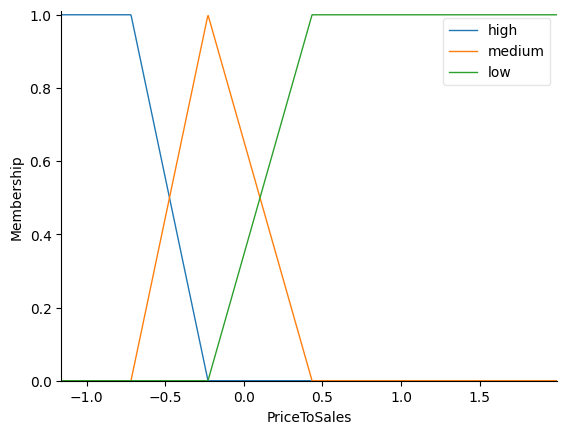

In [15]:
q_min = price_to_sales_min_val
q_low = df['PriceToSales'].quantile(LOW_QUANTILE)
q_mid = df['PriceToSales'].quantile(MID_QUANTILE)
q_high = df['PriceToSales'].quantile(HIGH_QUANTILE)
q_max = price_to_sales_max_val

universe_pts = price_to_sales_antecedent.universe

price_to_sales_antecedent['high'] = fuzz.trapmf(universe_pts, [q_min, q_min, q_low, q_mid])
price_to_sales_antecedent['medium'] = fuzz.trimf(universe_pts, [q_low, q_mid, q_high])
price_to_sales_antecedent['low'] = fuzz.trapmf(universe_pts, [q_mid, q_high, q_max, q_max])

price_to_sales_antecedent.view()

#### 5) TARGET SCORE

In [16]:
universe_target = TARGET_SCORE.universe

# Parametr sigma określa "szerokość" dzwonu Gaussa.
# Przy środkach oddalonych od siebie o 20, sigma=10 daje idealny overlap (nachodzenie na siebie)
sigma_val = 10

TARGET_SCORE['very_low'] = fuzz.gaussmf(universe_target, 10, sigma_val)
TARGET_SCORE['low'] = fuzz.gaussmf(universe_target, 30, sigma_val)
TARGET_SCORE['medium'] = fuzz.gaussmf(universe_target, 50, sigma_val)
TARGET_SCORE['high'] = fuzz.gaussmf(universe_target, 70, sigma_val)
TARGET_SCORE['very_high'] = fuzz.gaussmf(universe_target, 90, sigma_val)

#### 6) Fuzzy rules
- wszystkie metryki mają taką samą wagę
- jeśli wszystkie są high, to target_score very_high
- jeśli wszystkie są low, to target_score jest very_low

**Matematycznie:**

Metryka ma:
- low = 1 pkt
- medium = 3 pkt
- high = 5 pkt

max_pkt = 15, min_pkt = 3. 
5 membership dla Target Score, czyli granica co 2.4:

**Target_Score:**
- (3, 5.4] - very_low
- (5.4, 7.8] - low
- (7.8, 10.2] - medium
- (10.2, 12.6] - high
- (12.6, 15] - very_high

In [17]:
etg = earnings_to_growth_antecedent
pmw = profit_margin_WMA_antecedent
pts = price_to_sales_antecedent

# ==========================================
# GRUPA 1: EarningsToGrowth na poziomie LOW
# ==========================================
rule1 = ctrl.Rule(etg['low'] & pmw['low'] & pts['low'], TARGET_SCORE['very_low'])
rule2 = ctrl.Rule(etg['low'] & pmw['low'] & pts['medium'], TARGET_SCORE['very_low'])
rule3 = ctrl.Rule(etg['low'] & pmw['low'] & pts['high'], TARGET_SCORE['low'])

rule4 = ctrl.Rule(etg['low'] & pmw['medium'] & pts['low'], TARGET_SCORE['very_low'])
rule5 = ctrl.Rule(etg['low'] & pmw['medium'] & pts['medium'], TARGET_SCORE['low'])
rule6 = ctrl.Rule(etg['low'] & pmw['medium'] & pts['high'], TARGET_SCORE['medium'])

rule7 = ctrl.Rule(etg['low'] & pmw['high'] & pts['low'], TARGET_SCORE['low'])
rule8 = ctrl.Rule(etg['low'] & pmw['high'] & pts['medium'], TARGET_SCORE['medium'])
rule9 = ctrl.Rule(etg['low'] & pmw['high'] & pts['high'], TARGET_SCORE['high'])

# ==========================================
# GRUPA 2: EarningsToGrowth na poziomie MEDIUM
# ==========================================
rule10 = ctrl.Rule(etg['medium'] & pmw['low'] & pts['low'], TARGET_SCORE['very_low'])
rule11 = ctrl.Rule(etg['medium'] & pmw['low'] & pts['medium'], TARGET_SCORE['low'])
rule12 = ctrl.Rule(etg['medium'] & pmw['low'] & pts['high'], TARGET_SCORE['medium'])

rule13 = ctrl.Rule(etg['medium'] & pmw['medium'] & pts['low'], TARGET_SCORE['low'])
rule14 = ctrl.Rule(etg['medium'] & pmw['medium'] & pts['medium'], TARGET_SCORE['medium'])
rule15 = ctrl.Rule(etg['medium'] & pmw['medium'] & pts['high'], TARGET_SCORE['high'])

rule16 = ctrl.Rule(etg['medium'] & pmw['high'] & pts['low'], TARGET_SCORE['medium'])
rule17 = ctrl.Rule(etg['medium'] & pmw['high'] & pts['medium'], TARGET_SCORE['high'])
rule18 = ctrl.Rule(etg['medium'] & pmw['high'] & pts['high'], TARGET_SCORE['very_high'])

# ==========================================
# GRUPA 3: EarningsToGrowth na poziomie HIGH
# ==========================================
rule19 = ctrl.Rule(etg['high'] & pmw['low'] & pts['low'], TARGET_SCORE['low'])
rule20 = ctrl.Rule(etg['high'] & pmw['low'] & pts['medium'], TARGET_SCORE['medium'])
rule21 = ctrl.Rule(etg['high'] & pmw['low'] & pts['high'], TARGET_SCORE['high'])

rule22 = ctrl.Rule(etg['high'] & pmw['medium'] & pts['low'], TARGET_SCORE['medium'])
rule23 = ctrl.Rule(etg['high'] & pmw['medium'] & pts['medium'], TARGET_SCORE['high'])
rule24 = ctrl.Rule(etg['high'] & pmw['medium'] & pts['high'], TARGET_SCORE['very_high'])

rule25 = ctrl.Rule(etg['high'] & pmw['high'] & pts['low'], TARGET_SCORE['high'])
rule26 = ctrl.Rule(etg['high'] & pmw['high'] & pts['medium'], TARGET_SCORE['very_high'])
rule27 = ctrl.Rule(etg['high'] & pmw['high'] & pts['high'], TARGET_SCORE['very_high'])

rules = [
    rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9,
    rule10, rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18,
    rule19, rule20, rule21, rule22, rule23, rule24, rule25, rule26, rule27
]

### Klasyfikacja spółek

In [18]:
import numpy as np
from pathlib import Path

SCORING_CTRL = ctrl.ControlSystem(rules)
scoring_sim = ctrl.ControlSystemSimulation(SCORING_CTRL)

target_scores = []

for index, row in df.iterrows():
    try:
        # Po lewej stronie: klucze użyte w ctrl.Antecedent(..., 'KLUCZ')
        # Po prawej stronie: faktyczne wartości z kolumn Twojego DataFrame (df)
        
        scoring_sim.input['Earnings-to-Growth'] = row['Earnings-to-Growth']
        scoring_sim.input['ProfitMargin_WMA'] = row['ProfitMargin_WMA']
        scoring_sim.input['PriceToSales'] = row['PriceToSales']

        scoring_sim.compute()
        score = scoring_sim.output['TARGET_SCORE']

        target_scores.append(round(score, 2))
        print(f"[{index + 1}/{len(df)}] Firma: {row['CompanyName']:<20} | Score: {score:.2f}")
        
    except Exception as e:
        # Obsługa błędów: jeśli w wierszu brakuje danych (np. NaN z powodu dzielenia przez zero), 
        print(f"!!! Błąd przy firmie {row['CompanyName']}: {e}")
        target_scores.append(np.nan)

df['TARGET_SCORE'] = target_scores

output_filename = LOCAL_FOLDER / 'scored_company_data_NEW_RULES.csv'
df.to_csv(output_filename, index=False)

print("-" * 50)
print(f"Sukces! Symulacja zakończona dla {len(df)} firm.")
print(f"Wyniki zostały zapisane do pliku: {output_filename}")

# (Opcjonalnie) Wyświetlenie top 5 najlepiej ocenionych firm prosto w Notebooku
df_sorted = df.sort_values(by='TARGET_SCORE', ascending=False)
display(df_sorted[['CompanyName', 'TARGET_SCORE']].head(5))

[1/1000] Firma: Company_1            | Score: 69.05
[2/1000] Firma: Company_2            | Score: 27.65
[3/1000] Firma: Company_3            | Score: 72.84
[4/1000] Firma: Company_4            | Score: 30.09
[5/1000] Firma: Company_5            | Score: 54.62
[6/1000] Firma: Company_6            | Score: 12.88
[7/1000] Firma: Company_7            | Score: 13.96
[8/1000] Firma: Company_8            | Score: 58.66
[9/1000] Firma: Company_9            | Score: 58.25
[10/1000] Firma: Company_10           | Score: 56.66
[11/1000] Firma: Company_11           | Score: 30.09
[12/1000] Firma: Company_12           | Score: 30.09
[13/1000] Firma: Company_13           | Score: 67.60
[14/1000] Firma: Company_14           | Score: 51.36
[15/1000] Firma: Company_15           | Score: 55.01
[16/1000] Firma: Company_16           | Score: 40.25
[17/1000] Firma: Company_17           | Score: 52.21
[18/1000] Firma: Company_18           | Score: 32.78
[19/1000] Firma: Company_19           | Score: 59.90
[2

,CompanyName,TARGET_SCORE
256,Company_257,87.37
33,Company_34,87.36
170,Company_171,87.33
808,Company_809,85.88
289,Company_290,84.63
